  ## STUDENT NAME :- Nikhil Shivaji Mali
  ## DIV:- B
  ## PEACTICAL BATCH:- B-1
  ## ROLL NO:- 03
  ## DATE:- 30/09/2026
  ## PRACTICAL NO:- 04
  ## PRACTICAL NAME:- Implementation of K-Nearest Neighbors (KNN) Classification using Social Network Ads Dataset 

# 1. Import Libraries

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt 


from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 2. Load CSV

In [4]:
df = pd.read_csv("Social_Network_Ads.csv")

print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15600000    Male   41            71570          1
1  15600001  Female   28            16015          1
2  15600002    Male   25            76813          0
3  15600003    Male   53            42712          1
4  15600004    Male   55           115497          1


# 3. EDA

In [5]:
print(df.shape)  # (rows, columns)

df['Purchased'].value_counts()

(400, 5)


Purchased
1    260
0    140
Name: count, dtype: int64

# 4. Scatter Plot

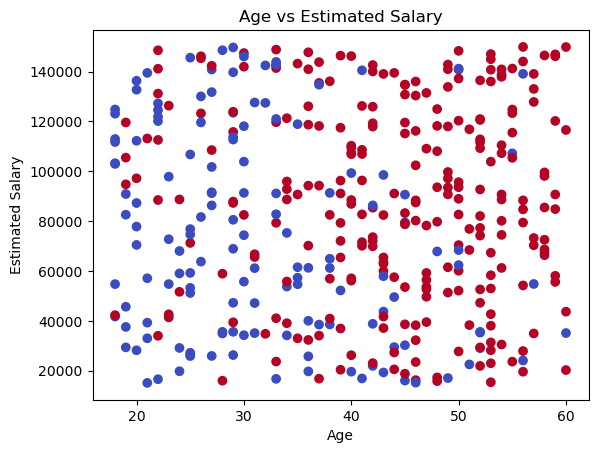

In [6]:
# Scatter Plot to show Unlinear data
plt.scatter(
    df['Age'],
    df['EstimatedSalary'],
    cmap='coolwarm',
    c=df['Purchased']
)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Age vs Estimated Salary")
plt.show()

# 5. Feature Selection

In [7]:
# Select features and target

X = df[['Age', 'EstimatedSalary']]  # Features
y = df['Purchased']                 # Target

# 6. Split Data

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 7. Scale the Data

In [9]:
scaler = StandardScaler()  # mean=0, std=1

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 8. Model Building — Train KNN

In [10]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

y_pred

array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1])

# 9. Classification Report / Accuracy

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7375


# 10. Visualize KNN Classification

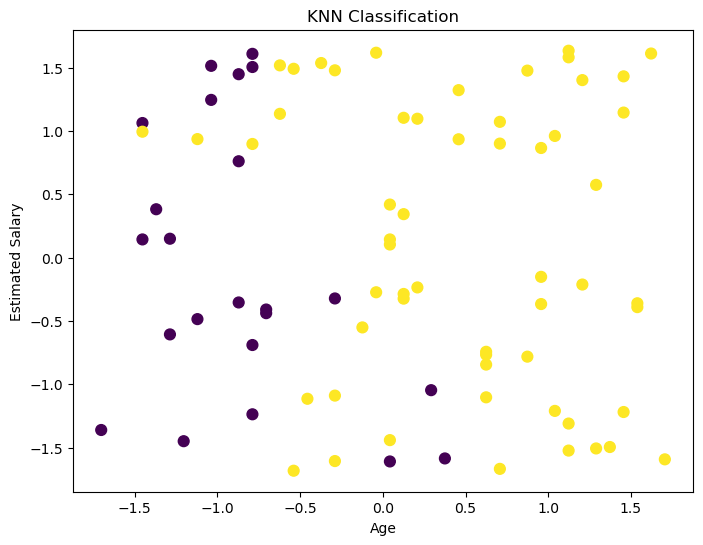

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_pred,
    cmap='viridis',
    s=60
)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("KNN Classification")

plt.show()

# 11. Tune K

In [13]:
# Train no of k values

k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

    print("K =", k, "Accuracy =", round(accuracy, 3))

K = 1 Accuracy = 0.725
K = 2 Accuracy = 0.713
K = 3 Accuracy = 0.775
K = 4 Accuracy = 0.762
K = 5 Accuracy = 0.738
K = 6 Accuracy = 0.75
K = 7 Accuracy = 0.75
K = 8 Accuracy = 0.762
K = 9 Accuracy = 0.738
K = 10 Accuracy = 0.75
K = 11 Accuracy = 0.775
K = 12 Accuracy = 0.8
K = 13 Accuracy = 0.775
K = 14 Accuracy = 0.8
K = 15 Accuracy = 0.775


# 12. Model Evaluation — Plot K vs Accuracy

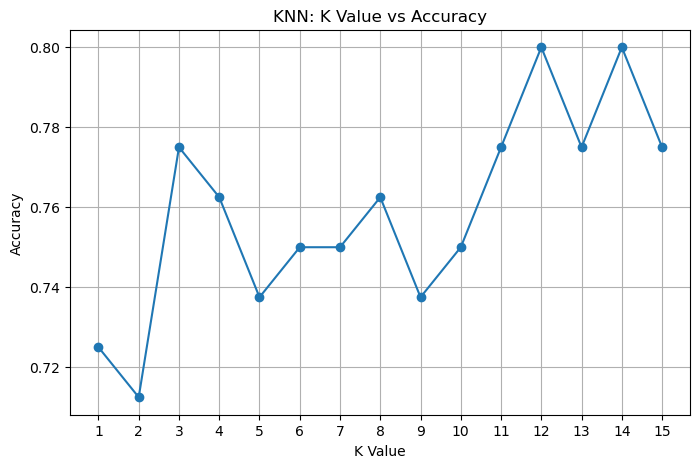

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker='o'
)  # Line Plot

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN: K Value vs Accuracy")

plt.xticks(k_values)
plt.grid()

plt.show()

# 13. Find Best K and Accuracy

In [15]:
# Finding best k and accuracy value

best_k = k_values[accuracies.index(max(accuracies))]

print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

Best K: 12
Best Accuracy: 0.8
